In [6]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# LOAD JSON LINES METADATA
metadata_df = pd.read_json('../data/raw/games_metadata.json', lines=True)

# SHOW BASIC INFO
print(metadata_df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50872 entries, 0 to 50871
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   app_id       50872 non-null  int64 
 1   description  50872 non-null  object
 2   tags         50872 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.2+ MB
None


In [3]:
# CHECK MISSING VALUES
print(metadata_df.isnull().sum())

app_id         0
description    0
tags           0
dtype: int64


In [4]:
# LOAD CLEANED GAMES TO FILTER OUT ORPHANED METADATA
games_df = pd.read_csv('../data/processed/games_cleaned.csv')
valid_app_ids = set(games_df['app_id'])

# KEEP ONLY METADATA FOR EXISTING GAMES
cleaned_metadata_df = metadata_df[metadata_df['app_id'].isin(valid_app_ids)]

print(f"REMOVED {len(metadata_df) - len(cleaned_metadata_df)} ORPHANED METADATA RECORDS.")


REMOVED 0 ORPHANED METADATA RECORDS.


In [ ]:
# 1. We create the description length column
# This helps us see if there are games with very poor descriptions
cleaned_metadata_df['desc_len'] = cleaned_metadata_df['description'].str.len()

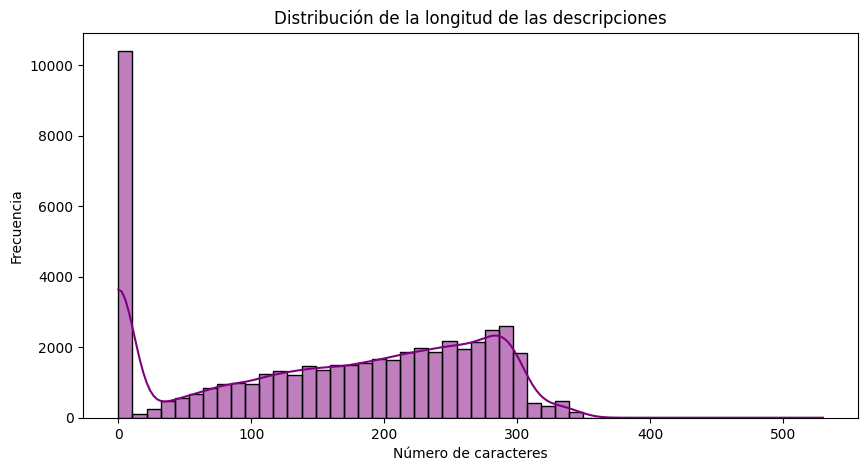

In [ ]:
# 2. Description Length Chart
plt.figure(figsize=(10, 5))
sns.histplot(cleaned_metadata_df['desc_len'], bins=50, color='purple', kde=True)
plt.title('Distribution of Description Lengths')
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.show()

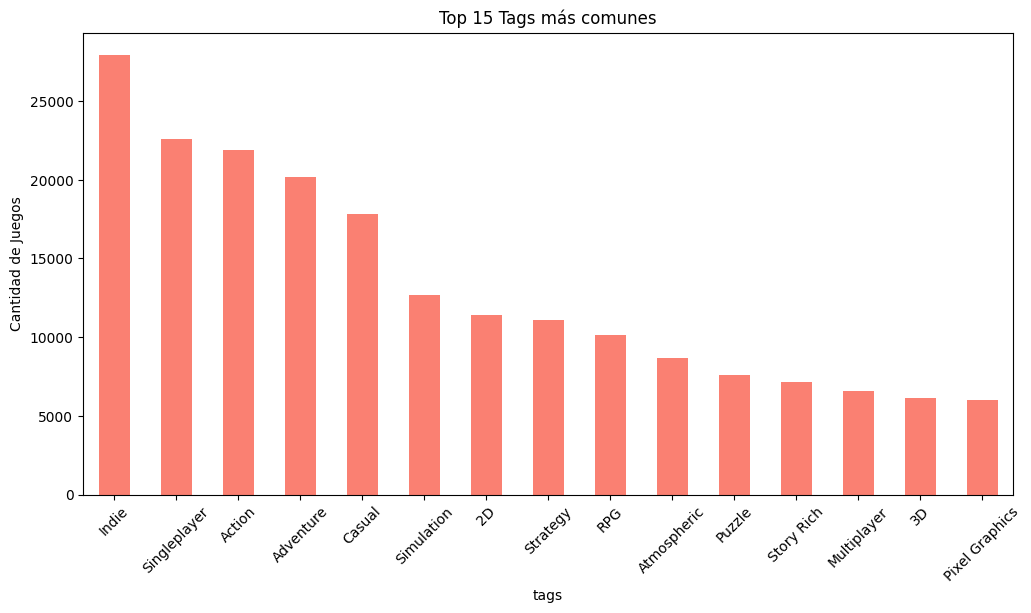

In [ ]:
# 3. Chart of Tags (the one I showed you before)
plt.figure(figsize=(12, 6))
all_tags = cleaned_metadata_df.explode('tags')
all_tags['tags'].value_counts().head(15).plot(kind='bar', color='salmon')
plt.title('Top 15 Most Common Tags')
plt.ylabel('Number of Games')
plt.xticks(rotation=45)
plt.show()

Metadata original: 50872
Metadata limpia: 50872


C:\Users\Lucero\AppData\Local\Temp\ipykernel_30444\2656898256.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Original', 'Filtered'], y=[len(metadata_df), len(cleaned_metadata_df)], palette='viridis')


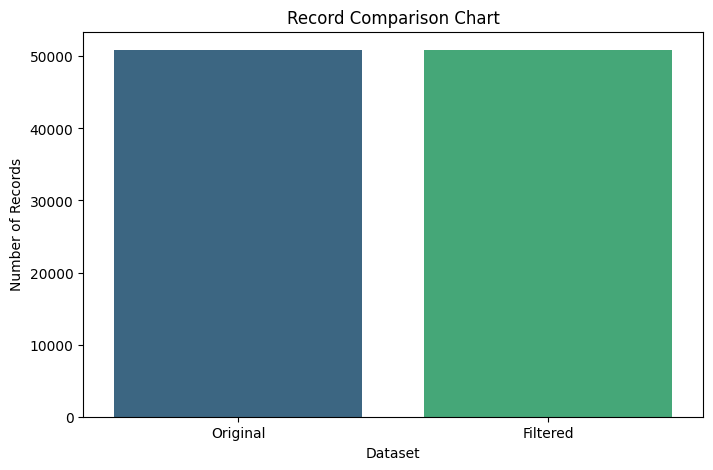

In [12]:
# VIEJO VS LO NUEVO
print(f"Metadata original: {len(metadata_df)}")
print(f"Metadata limpia: {len(cleaned_metadata_df)}")

# Record comparison chart
plt.figure(figsize=(8, 5))
sns.barplot(x=['Original', 'Filtered'], y=[len(metadata_df), len(cleaned_metadata_df)], palette='viridis')
plt.title('Record Comparison Chart')
plt.xlabel('Dataset')
plt.ylabel('Number of Records')
plt.show()

In [11]:
# SAVE CLEANED METADATA AS JSON LINES
cleaned_metadata_df.to_json('../data/processed/games_metadata_cleaned.json', orient='records', lines=True)
print("CLEANED METADATA SAVED.")


CLEANED METADATA SAVED.
